In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd_project.config.config import load_config 
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    preliminary_record_selection,
    optimise_record_selection,
)

from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA03_gm_selection import setup_AvgSA03_gcim_gm_selection


cfg = load_config()

C:\Users\clemettn\Documents\phd\phd_project\scripts\WP1_ground_motion_set\gm_selection.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# AvgSA([0, 3])

In [3]:
# file paths:
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_03.pickle"
preliminary_selection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_prelim_selection.pickle"
preliminary_reselection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_prelim_reselection.pickle"
optimised_selection_rd1_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_optimised_selection_rd01.pickle"
optimised_selection_rd2_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_optimised_selection_rd02.pickle"
esm_records_to_download_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_esm_records_to_download.csv"
ngasub_records_to_download_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_ngasub_records_to_download.csv"

# other stuff:
rng_seed = 1

LOAD_RS_IF_EXISTS = True
LOAD_OPTIMISED_ENSEMBLES_IF_EXISTS = True

In [4]:
# set up the record selection
site_poe_disaggs, disagg_stats, site_model, basic_selection_ctx, gm_db = setup_AvgSA03_gcim_gm_selection()

# load the gcim distributions
if gcim_dist_fp.is_file():
    with open(gcim_dist_fp, "rb") as file:
        gcim_dists = pickle.load(file)
    print("Existing GCIM distribution data loaded...")
else:
    print("No existing GCIM distribution data found...")

Existing GCIM distribution data loaded...


## Preliminary Selection

 First go a preliminary selection. Using the Tarbali and Bradley recommendations for bounds on causal parameters.

In [5]:
only_select = []

preliminary_ensembles, prelim_ensembles_not_passing, no_preliminary_ensembles, _ = preliminary_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    basic_selection_ctx, 
    site_model, 
    rng_seed, 
    preliminary_selection_fp=preliminary_selection_fp, 
    only_select=only_select, 
    load_rs_if_exists=LOAD_RS_IF_EXISTS)

Existing record selection data loaded...
Sub-Optimal! - Preliminary ensembles do not pass for 11 combinations of site and poe
No preliminary ensembles found for 2 combinations of site and poe


In [6]:
no_preliminary_ensembles

[(30, np.float64(0.000201)), (30, np.float64(0.0001))]

## Optimisation of Ensembles

### Round 1

Optimisation using the same parameters as the original selection. This will only optimise the ensembles that didn't pass the preliminary selection.

In [7]:
only_optimise = prelim_ensembles_not_passing

optimised_ensembles, optimised_ensembles_not_passing_rd1 = optimise_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    basic_selection_ctx, 
    site_model, 
    preliminary_ensembles,
    optimised_selection_fp=optimised_selection_rd1_fp,
    only_optimise=only_optimise,
    shuffle=False,
    rng_seed=rng_seed, 
    load_rs_if_exists=LOAD_OPTIMISED_ENSEMBLES_IF_EXISTS)

Existing optimised ensembles loaded...
Sub-Optimal! - Optimised ensembles do not pass for 4 combinations of site and poe


In [8]:
optimised_ensembles_not_passing_rd1

[(30, np.float64(0.000201)),
 (30, np.float64(0.0001)),
 (37, np.float64(0.0001)),
 (46, np.float64(0.0001))]

Of the four combinations of site and poe, preliminary ensembles couldn't be found for two of them. For these cases a reselection is required. In the other two cases we can improve the distribution by redoing the optimisation without any bounds on the distance, magnitude and/or vs30

## Reselection

Reselection is performed considering no bound on the distance.

In [9]:
only_select = no_preliminary_ensembles

basic_reselection_ctx = basic_selection_ctx.copy()
basic_reselection_ctx["d_bound_model"] = None

reselected_ensembles, reselected_ensembles_not_passing, no_reselected_ensembles, _ = preliminary_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    basic_reselection_ctx, 
    site_model, 
    rng_seed, 
    preliminary_selection_fp=preliminary_reselection_fp, 
    only_select=only_select, 
    load_rs_if_exists=LOAD_RS_IF_EXISTS)

Existing record selection data loaded...
OK! - Preliminary ensembles pass for all combinations of site and poe


In [10]:
# combine the reselected ensemble with the other preliminary ensembles
for k, v in reselected_ensembles.items():
    preliminary_ensembles[k] = v

### Round 2

Optimisation with no bounds on distance.

In [11]:
only_optimise = optimised_ensembles_not_passing_rd1

rd2_basic_selection_ctx = basic_selection_ctx.copy()
rd2_basic_selection_ctx["d_bound_model"] = None

optimised_ensembles_rd2, optimised_ensembles_not_passing_rd2 = optimise_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    rd2_basic_selection_ctx, 
    site_model, 
    preliminary_ensembles,
    optimised_selection_fp=optimised_selection_rd2_fp,
    only_optimise=only_optimise,
    shuffle=False,
    rng_seed=rng_seed, 
    load_rs_if_exists=LOAD_OPTIMISED_ENSEMBLES_IF_EXISTS)

Existing optimised ensembles loaded...
OK! - Optimised ensembles pass for all combinations of site and poe


When all of the optimisations have passed combine them

In [12]:
final_ensembles = preliminary_ensembles.copy()
final_ensembles.update(optimised_ensembles)
final_ensembles.update(optimised_ensembles_rd2)

# Post-Processing

In [13]:
# Save the best ensembles in the results folder
RESULT_FOLDER = cfg["results"]["AvgSA_03_record_selection"]

for (site, poe), ensemble in final_ensembles.items():

    if not ensemble["ks_passed"]:
        print(f"No valid ensemble: Site {site} - poe = {poe}")
        continue
    
    tag = "__".join([f"site_{site}", f"{poe:g}".replace(".", "pt")])
    
    # Add the gcim_quantiles from the result
    ensemble["gcim_quantiles"] = gcim_dists[(site, poe)]["stats"]

    # calculate the trt %'s
    trt_stats = pd.DataFrame(
        ensemble["recs"].groupby(("metadata", "trt")).size())
    trt_stats.columns = ["count"]
    trt_stats["proportions"] = np.round(trt_stats["count"] / \
                                        trt_stats["count"].sum(), 3)
    ensemble["trt_stats"] = trt_stats

    # Surface RSN + a stable record identifier and JSON filename per record.
    recs = ensemble["recs"]
    is_ngasub = recs[("metadata", "database")] == "NGASub"

    # RSN: already present as metadata.index for NGASub; NA for ESM.
    recs[("metadata", "RSN")] = (
        recs[("metadata", "index")].astype("string").where(is_ngasub)
    )

    # record_identifier: ESM uses event/station/location; NGASub uses the RSN.
    esm_id = (
        recs[("metadata", "event_id")].astype(str) + "_"
        + recs[("metadata", "station_code")].astype(str) + "_"
        + recs[("metadata", "location_code")].astype(str)
    )
    recs[("metadata", "record_identifier")] = esm_id.where(
        ~is_ngasub, recs[("metadata", "index")].astype(str)
    )

    # filename: {record_identifier}__{component}.json
    recs[("metadata", "filename")] = (
        recs[("metadata", "record_identifier")].astype(str)
        + "__" + recs[("metadata", "component")].astype(str) + ".json"
    )

    with open(RESULT_FOLDER / f"{tag}__gm_selection.pickle", "wb") as file:
        pickle.dump(ensemble, file)
            

## Identify the number of unique records and unique events across all sites

In [14]:
# combine all ensembles into one dataframe
rec_dfs = []
for e in final_ensembles.values():
    rec_dfs.append(e["recs"])

all_recs = pd.concat(rec_dfs, axis=0)
events = all_recs.groupby(("metadata", "event_id")).size().sort_values(ascending=False)
events = pd.DataFrame(events, columns=["count"])
events["cum_sum"] = events["count"].cumsum() 
events["cum_%"] = np.round(events["cum_sum"] / events["count"].sum(), 4)

recs_and_events = all_recs.reset_index().groupby([("metadata", "event_id"), "index"])\
    .size().sort_values(ascending=False)
recs_and_events = pd.DataFrame(recs_and_events, columns=["count"])
recs_and_events["cum_sum"] = recs_and_events["count"].cumsum() 
recs_and_events["cum_%"] = np.round(recs_and_events["cum_sum"] / recs_and_events["count"].sum(), 4)
recs_and_events

print(f"Number of unique events: {len(events)}")
print(f"Number of unique records: {len(recs_and_events)}")
print(f"Maximum number of times a record was selected: {recs_and_events["count"].iloc[0]} ({recs_and_events["count"].iloc[0] / len(all_recs)*100:.2f} %)")

Number of unique events: 361
Number of unique records: 2423
Maximum number of times a record was selected: 110 (1.02 %)


In [15]:
recs_and_events

count  cum_sum   cum_%
(metadata, event_id)  index                        
ME-1979-0003          19941    110      110  0.0102
GR-1999-0001          12305    103      213  0.0197
IT-1997-0137          12974     95      308  0.0285
EMSC-20161030_0000029 31173     87      395  0.0366
IT-2009-0009          34772     86      481  0.0445
...                            ...      ...     ...
EMSC-20140126_0000085 2712       1    10796  0.9996
                      2706       1    10797  0.9997
EMSC-20140126_0000046 23627      1    10798  0.9998
                      23624      1    10799  0.9999
EMSC-20131112_0000077 2419       1    10800  1.0000

[2423 rows x 3 columns]

(0.0, 378.0)

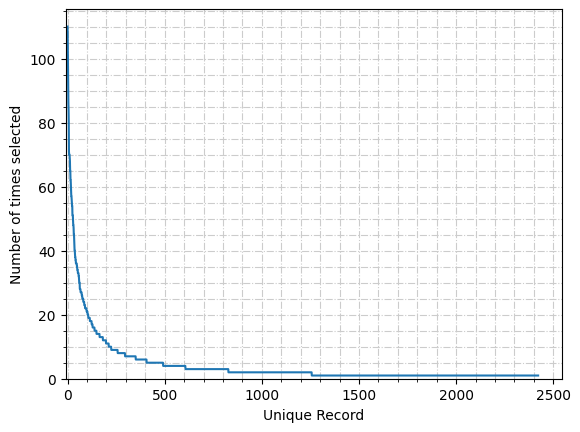

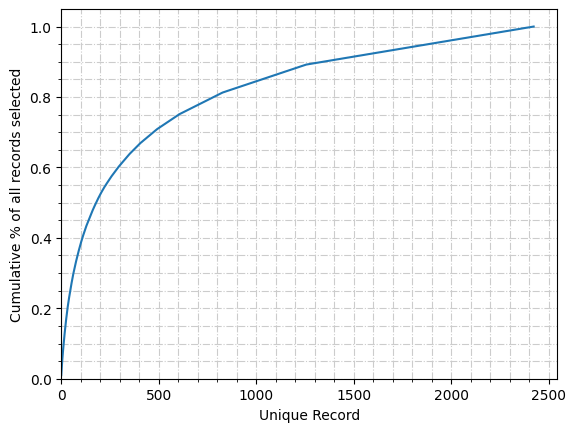

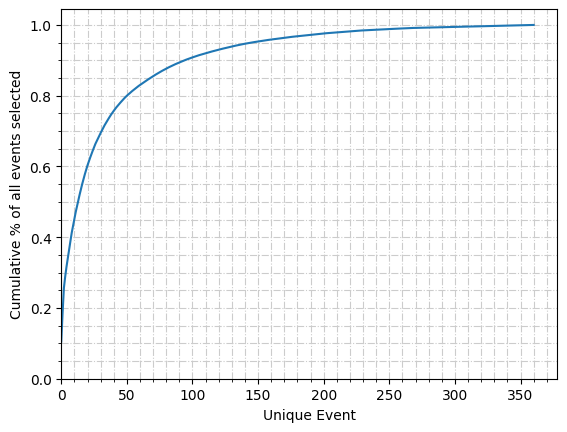

In [16]:
fig, ax3 = plt.subplots()
ax3.plot(recs_and_events["count"].to_numpy())
ax3.grid(True, which="both", ls="-.", color="0.8")
ax3.minorticks_on()
ax3.set_xlabel("Unique Record")
ax3.set_ylabel("Number of times selected")
ax3.set_ylim(0)
ax3.set_xlim(-10)

fig, ax1 = plt.subplots()
ax1.plot(recs_and_events["cum_%"].to_numpy())
ax1.grid(True, which="both", ls="-.", color="0.8")
ax1.minorticks_on()
ax1.set_xlabel("Unique Record")
ax1.set_ylabel("Cumulative % of all records selected")
ax1.set_ylim(0)
ax1.set_xlim(0)

fig, ax2 = plt.subplots()
ax2.plot(events["cum_%"].to_numpy())
ax2.grid(True, which="both", ls="-.", color="0.8")
ax2.minorticks_on()
ax2.set_xlabel("Unique Event")
ax2.set_ylabel("Cumulative % of all events selected")
ax2.set_ylim(0)
ax2.set_xlim(0)


In [17]:
cols_to_keep = [("metadata", "event_id"), ("metadata", "station_code"), ("metadata", "location_code")]
unique_esm_records = all_recs[all_recs[("metadata", "database")] == "ESM"]\
                     .drop_duplicates(subset=cols_to_keep)
unique_esm_records = unique_esm_records[cols_to_keep].reset_index(drop=True)
esm_records_to_download = unique_esm_records
esm_records_to_download.to_csv(esm_records_to_download_fp, index=False)

In [18]:
# For the NGASub records we need the NGAsubRSN for each combination of event_id and station_code
NGASub_records = all_recs[all_recs[("metadata", "database")] == "NGASub"]
unique_NGASub_id_counts = NGASub_records.groupby(
    [("metadata", "event_id"), ("metadata", "station_code")]).size().sort_values(ascending=False)
unique_NGASub_id_counts = unique_NGASub_id_counts.rename("count")

# load the NGASub database
ngasub_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_Metadata_SA_rotD50.csv"
ngasub_db = pd.read_csv(ngasub_fp, header=0, encoding="cp1252", dtype=str)
new_index = list(ngasub_db[["NGAsubEQID", "NGAsubSSN"]].itertuples(index=False, name=None))
ngasub_db.index = new_index
ngasub_db = ngasub_db["NGAsubRSN"]

# RSNs to download
rsns_to_download = ngasub_db.loc[unique_NGASub_id_counts.index]
rsns_to_download = pd.concat([rsns_to_download, unique_NGASub_id_counts], axis=1)
rsns_to_download.to_csv(ngasub_records_to_download_fp, index=False)

In [19]:
# Per-campaign record-conversion list (record_identifier, component, database)
# for the AT2/HDF5 -> JSON converters. Combined across campaigns in
# wp1pt3pt8i-organise_records_to_download.
records_to_convert = (
    all_recs["metadata"][["record_identifier", "component", "database"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
records_to_convert.to_csv(
    cfg["proc_data"]["gm_selection"] / "AvgSA_03_records_to_convert.csv",
    index=False,
)
